In [1]:
# Imports and setup
import pandas as pd
import pyarrow.parquet as pq
import pyarrow as pa

import os
import time

print("All libraries imported successfully!")

All libraries imported successfully!


# Remote Schema expolaration

In [2]:
PATHS = {
    "Blocks": "../data/raw/blocks.parquet",
    "Follows": "../data/raw/follows.parquet",
    "Likes": "../data/raw/likes.parquet",
    "Posts": "../data/raw/posts.parquet",
    "Profiles": "../data/raw/profiles.parquet"
}

In [3]:
def get_column_metadata(path, column_names=None, detailed=False, sample_rows=1000, top_k=10):
    """
    Inspect Parquet column metadata and perform small-sample EDA using row-group sampling.

    This simplified function only supports local parquet files (e.g. "../data/raw/posts.parquet").
    It reads Parquet metadata (fast) and then samples up to `sample_rows` by reading
    successive row groups until the sampling budget is met. The sample is used to compute
    value counts, missing rates, and basic numeric statistics.

    Args:
        path: local path to a .parquet file
        column_names: None (all) or list/str of column names to inspect
        detailed: if True, print more verbose metadata and sample statistics
        sample_rows: max number of rows to sample from the file for EDA
        top_k: how many top frequent values to show for categorical fields
    """

    # Open the local parquet file directly (no remote/fsspec support)
    try:
        parquet_file = pq.ParquetFile(path)
        metadata = parquet_file.metadata
        schema = parquet_file.schema_arrow
    except Exception as e:
        print(f"Error opening parquet file {path}: {e}")
        return

    print(schema)

    # Normalize requested columns
    if column_names is None:
        column_names = schema.names
    elif isinstance(column_names, str):
        column_names = [column_names]

    valid_columns = [c for c in column_names if c in schema.names]
    missing_columns = [c for c in column_names if c not in schema.names]
    if missing_columns:
        print(f"Warning: these requested columns not present: {missing_columns}")

    if not valid_columns:
        print("No valid columns to analyze")
        return

    mode = "DETAILED" if detailed else "OVERVIEW"
    print(f"=== {mode} FOR {len(valid_columns)} COLUMN(S) in {path} ===")
    print(f"Parquet row groups: {metadata.num_row_groups:,}, total rows (metadata): {metadata.num_rows:,}")

    # Build a sample by reading row-groups until sample_rows reached
    sample_frames = {col: [] for col in valid_columns}
    rows_accum = 0

    for rg_idx in range(metadata.num_row_groups):
        if rows_accum >= sample_rows:
            break
        try:
            # Read only the columns we will inspect to reduce IO
            # read_row_group accepts a list of column names
            tbl = parquet_file.read_row_group(rg_idx, columns=valid_columns)
            df_rg = tbl.to_pandas()
            n_rg = len(df_rg)
            if n_rg == 0:
                continue
            # Append per-column slices
            for col in valid_columns:
                sample_frames[col].append(df_rg[[col]])
            rows_accum += n_rg
        except Exception as e:
            # If a row-group read fails, continue (file may be partially corrupted)
            if detailed:
                print(f"Warning: failed reading row group {rg_idx}: {e}")
            continue

    # Concatenate samples per column and trim to sample_rows
    samples = {}
    for col in valid_columns:
        try:
            if sample_frames[col]:
                df_col = pd.concat(sample_frames[col], ignore_index=True)
                if len(df_col) > sample_rows:
                    df_col = df_col.iloc[:sample_rows]
                samples[col] = df_col[col]
            else:
                samples[col] = pd.Series([], dtype=object)
        except Exception as e:
            samples[col] = pd.Series([], dtype=object)
            if detailed:
                print(f"Could not build sample for {col}: {e}")

    # Inspect each column using metadata and sample
    for column_name in valid_columns:
        col_idx = schema.names.index(column_name)
        col_type = schema.field(column_name).type

        # Metadata-level aggregations (fast, from Parquet statistics)
        total_nulls = 0
        total_values = 0
        has_min_max = False
        global_min = None
        global_max = None
        has_distinct_count = False
        distinct_count = None

        for rg_idx in range(metadata.num_row_groups):
            try:
                rg_metadata = metadata.row_group(rg_idx)
                col_metadata = rg_metadata.column(col_idx)
                rg_num_rows = rg_metadata.num_rows
                if col_metadata.statistics:
                    stats = col_metadata.statistics
                    if getattr(stats, 'has_null_count', False):
                        total_nulls += getattr(stats, 'null_count', 0) or 0
                    if getattr(stats, 'has_min_max', False) or getattr(stats, 'min', None) is not None:
                        has_min_max = True
                        try:
                            current_min = stats.min
                            current_max = stats.max
                            if pa.types.is_timestamp(col_type):
                                current_min = pa.scalar(current_min).cast(col_type).as_py()
                                current_max = pa.scalar(current_max).cast(col_type).as_py()
                            if global_min is None or (current_min is not None and current_min < global_min):
                                global_min = current_min
                            if global_max is None or (current_max is not None and current_max > global_max):
                                global_max = current_max
                        except Exception:
                            if global_min is None:
                                global_min = getattr(stats, 'min', None)
                                global_max = getattr(stats, 'max', None)
                    if getattr(stats, 'has_distinct_count', False):
                        has_distinct_count = True
                        dc = getattr(stats, 'distinct_count', None)
                        if distinct_count is None or (dc and dc > distinct_count):
                            distinct_count = dc
                total_values += rg_num_rows
            except Exception:
                continue

        null_percentage = (total_nulls / total_values) * 100 if total_values > 0 else 0
        non_null_count = total_values - total_nulls

        print('\n' + ('=' * 60))
        print(f"Column: {column_name}")
        print(f"Arrow type: {col_type}")
        print(f"Metadata rows covered: {total_values:,}")
        print(f"Nulls (metadata): {total_nulls:,} ({null_percentage:.2f}%)")
        if has_min_max:
            try:
                print(f"Min/Max (metadata): {global_min} → {global_max}")
            except Exception:
                print("Min/Max (metadata): available (display error)")
        else:
            print("Min/Max (metadata): not available")
        if has_distinct_count:
            print(f"Distinct values (approx from metadata): {distinct_count}")

        # Sample-level EDA (may be empty if sampling failed)
        s = samples.get(column_name)
        if s is None or s.empty:
            print("No sample available for this column (small file or row-group read failed)")
            continue

        # Convert timestamp-like arrow types to pandas datetime if needed
        is_timestamp = pa.types.is_timestamp(col_type)
        is_numeric = pa.types.is_integer(col_type) or pa.types.is_floating(col_type)
        is_string = pa.types.is_string(col_type) or pa.types.is_large_string(col_type)

        # Basic sample stats
        try:
            sample_len = len(s)
            sample_nulls = s.isna().sum()
            sample_null_pct = 100.0 * sample_nulls / sample_len if sample_len > 0 else 0
            print(f"Sample rows used for EDA: {sample_len}")
            print(f"Nulls (sample): {sample_nulls} ({sample_null_pct:.2f}%)")

            if is_timestamp:
                s_conv = pd.to_datetime(s.dropna(), utc=True, errors='coerce')
                if not s_conv.empty:
                    print(f"Sample min/max (ts): {s_conv.min()} → {s_conv.max()}")
            elif is_numeric:
                s_num = pd.to_numeric(s, errors='coerce')
                if not s_num.dropna().empty:
                    print(s_num.describe())
            elif is_string:
                # show lengths and top values
                lens = s.dropna().astype(str).map(len)
                if not lens.empty:
                    print(f"Avg length (sample): {lens.mean():.1f} (median {lens.median():.1f})")
            # Top-k frequent values (use sample)
            top = s.dropna().astype(str).value_counts().head(top_k)
            if not top.empty:
                print(f"Top {top_k} frequent (sample):")
                print(top.to_string())

            # If detailed, show histogram-ish bins for numeric
            if detailed and is_numeric:
                import matplotlib.pyplot as plt
                try:
                    s_num = pd.to_numeric(s, errors='coerce').dropna()
                    if len(s_num) > 0:
                        print("Showing small numeric histogram (sample)")
                        plt.figure(figsize=(6,2))
                        plt.hist(s_num, bins=20)
                        plt.title(f"Histogram (sample) for {column_name}")
                        plt.show()
                except Exception as e:
                    print(f"Could not plot histogram for {column_name}: {e}")
        except Exception as e:
            print(f"Error computing sample stats for {column_name}: {e}")

    print('\nDone')


In [4]:
get_column_metadata(PATHS["Posts"], ["did_id", "created_date"], detailed=False)


did_id: int64
created_date: date32[day]
labels: extension<arrow.json>
languages: extension<arrow.json>
reply_root_did_id: int64
reply_parent_did_id: int64
=== OVERVIEW FOR 2 COLUMN(S) in ../data/raw/posts.parquet ===
Parquet row groups: 6,574, total rows (metadata): 812,390,294

Column: did_id
Arrow type: int64
Metadata rows covered: 812,390,294
Nulls (metadata): 0 (0.00%)
Min/Max (metadata): 57 → 34251846
Distinct values (approx from metadata): 8388
Sample rows used for EDA: 1000
Nulls (sample): 0 (0.00%)
count    1.000000e+03
mean     2.011764e+07
std      9.717692e+06
min      7.203570e+05
25%      1.156214e+07
50%      1.681375e+07
75%      2.838320e+07
max      3.414836e+07
Name: did_id, dtype: float64
Top 10 frequent (sample):
did_id
34148363    228
7742998     157
11562143    112
25635481     92
15835358     75
16104775     61
16813746     53
24144239     50
12139018     39
25271654     34

Column: created_date
Arrow type: date32[day]
Metadata rows covered: 812,390,294
Nulls (me

did_id: int64
created_date: date32[day]
labels: extension<arrow.json>
=== DETAILED FOR 2 COLUMN(S) in ../data/raw/profiles.parquet ===
Parquet row groups: 17, total rows (metadata): 2,050,745

Column: did_id
Arrow type: int64
Metadata rows covered: 2,050,745
Nulls (metadata): 0 (0.00%)
Min/Max (metadata): 57 → 34251846
Sample rows used for EDA: 1000
Nulls (sample): 0 (0.00%)
count      1000.00000
mean     401035.91100
std        5041.33666
min      392385.00000
25%      396572.25000
50%      401258.50000
75%      405407.25000
max      409544.00000
Name: did_id, dtype: float64
Top 10 frequent (sample):
did_id
392385    1
392400    1
392412    1
392446    1
392503    1
392514    1
392521    1
392531    1
392550    1
392566    1
Showing small numeric histogram (sample)


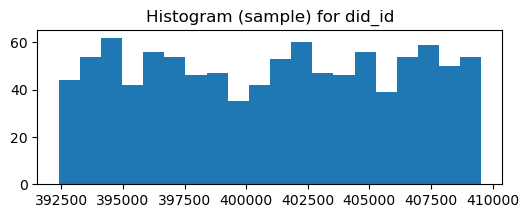


Column: created_date
Arrow type: date32[day]
Metadata rows covered: 2,050,745
Nulls (metadata): 408,168 (19.90%)
Min/Max (metadata): 1970-01-01 → 2954-08-31
Distinct values (approx from metadata): 438
Sample rows used for EDA: 1000
Nulls (sample): 182 (18.20%)
Top 10 frequent (sample):
created_date
2024-08-31    76
2024-11-14    39
2024-10-17    36
2024-08-30    32
2024-09-01    26
2024-11-15    26
2024-11-13    25
2024-11-16    22
2024-08-29    20
2024-11-11    19

Done


In [18]:
get_column_metadata(PATHS["Profiles"], ["did_id", "created_date"], detailed=True)

# Duck db cleaning 
Note: From the EDA we know that did_id and subject_id are never null, so we don't include them in the cleaning. 

In [5]:
# The majority of the blocks happens here.

MAX_DATE = '2025-05-01'
MIN_DATE = '2024-01-01'

In [7]:
import duckdb

# DuckDB-based cleaning helper function (with optional column projection)
def clean_parquet_with_duckdb(input_path, output_path, where_clause=None, columns=None, label=None, verbose=True):
    """
    Clean a parquet file using DuckDB and write the result as a parquet file (ZSTD compression).

    Args:
        input_path: path to the input parquet file
        output_path: path where the cleaned parquet will be written
        where_clause: optional SQL WHERE clause (string) to filter rows (without the WHERE keyword)
        columns: optional list of column names to select (e.g. ['did_id','created_date'])
        label: optional label for printed messages
        verbose: if True, print progress and statistics

    Returns:
        dict with statistics: elapsed_time, total_rows, filtered_rows, retention_rate, input_size_gb, output_size_gb
    """
    if label is None:
        label = os.path.basename(input_path)

    if verbose:
        print(f"Cleaning (DuckDB) → {label}")

    start_time = time.time()
    conn = duckdb.connect()
    
    conn.execute("PRAGMA memory_limit='4GB'")  # Use minimal memory
    conn.execute("SET threads=4")  # Reduce parallel processing
    conn.execute("SET preserve_insertion_order=false")  # Faster

    try:
        # Count total rows in the source file (no projection here; we need the full count)
        total_rows = conn.execute(f"SELECT COUNT(*) FROM read_parquet('{input_path}')").fetchone()[0]

        # Build the projection (columns) SQL
        if columns:
            # Simple join, assume caller provides valid column names
            cols_sql = ', '.join(columns)
        else:
            cols_sql = '*'

        # Build the SELECT SQL (with optional WHERE)
        if where_clause:
            select_sql = f"SELECT {cols_sql} FROM read_parquet('{input_path}') WHERE {where_clause}"
        else:
            select_sql = f"SELECT {cols_sql} FROM read_parquet('{input_path}')"

        # Use COPY to write a compressed parquet file efficiently
        copy_sql = f"COPY ({select_sql}) TO '{output_path}' (FORMAT PARQUET, COMPRESSION ZSTD);"
        conn.execute(copy_sql)

        # Count rows written
        filtered_rows = conn.execute(f"SELECT COUNT(*) FROM read_parquet('{output_path}')").fetchone()[0]
    finally:
        conn.close()

    elapsed = time.time() - start_time
    input_size = os.path.getsize(input_path) if os.path.exists(input_path) else 0
    output_size = os.path.getsize(output_path) if os.path.exists(output_path) else 0
    retention_rate = (filtered_rows / total_rows * 100) if total_rows > 0 else 0

    if verbose:
        print("\n✅ DuckDB cleaning completed")
        print(f"Time: {elapsed:.2f} sec")
        print(f"Rows: {total_rows:,} → {filtered_rows:,} ({retention_rate:.1f}% kept)")
        print(f"File size: {input_size / (1024**3):.3f} GB → {output_size / (1024**3):.3f} GB")
        print(f"Output: {output_path}")

    return {
        'elapsed_time': elapsed,
        'total_rows': total_rows,
        'filtered_rows': filtered_rows,
        'retention_rate': retention_rate,
        'input_size_gb': input_size / (1024**3),
        'output_size_gb': output_size / (1024**3),
    }

In [ ]:
# Posts
in_path = "../data/raw/posts.parquet"
out_path = "../data/ale_simplicistic_model/cleaned/posts.parquet"

cols = ['did_id', 'created_date']
where = "created_date IS NOT NULL AND created_date <= '{MAX_DATE}' AND created_date >= '{MIN_DATE}'".format(MAX_DATE=MAX_DATE, MIN_DATE=MIN_DATE)

stats_posts = clean_parquet_with_duckdb(in_path, out_path, where_clause=where, columns=cols, label="posts (duckdb, projected)")
print(stats_posts)

Cleaning (DuckDB) → posts (duckdb, projected)



✅ DuckDB cleaning completed
Time: 40.21 sec
Rows: 812,390,294 → 734,849,771 (90.5% kept)
File size: 4.855 GB → 0.963 GB
Output: ../data/user_activity/cleaned/posts.parquet
{'elapsed_time': 40.21119785308838, 'total_rows': 812390294, 'filtered_rows': 734849771, 'retention_rate': 90.45526225846318, 'input_size_gb': 4.854923024773598, 'output_size_gb': 0.9631761563941836}


In [ ]:
# Profiles
in_path = "../data/raw/profiles.parquet"
out_path = "../data/ale_simplicistic_model/cleaned/profiles.parquet"

# Subtract one month from MAX_DATE so that users who joined within the last month are excluded (we cannot observe their future behaviour beyond the dataset end).
profiles_max_dt = pd.to_datetime(MAX_DATE) - pd.DateOffset(months=1)
profiles_max_date = profiles_max_dt.strftime('%Y-%m-%d')
print(f"Original MAX_DATE: {MAX_DATE}, adjusted profiles_max_date (MAX_DATE - 1 month): {profiles_max_date}")

cols = ['did_id', 'created_date']
where = "did_id IS NOT NULL AND created_date IS NOT NULL AND created_date <= '{MAX_DATE}' AND created_date >= '{MIN_DATE}'".format(MAX_DATE=profiles_max_date, MIN_DATE=MIN_DATE)

stats_profiles = clean_parquet_with_duckdb(in_path, out_path, where_clause=where, columns=cols, label="profiles (duckdb, projected)")
print(stats_profiles)

Original MAX_DATE: 2025-05-01, adjusted profiles_max_date (MAX_DATE - 1 month): 2025-04-01
Cleaning (DuckDB) → profiles (duckdb, projected)

✅ DuckDB cleaning completed
Time: 0.19 sec
Rows: 2,050,745 → 1,604,575 (78.2% kept)
File size: 0.010 GB → 0.003 GB
Output: ../data/user_activity/cleaned/profiles.parquet
{'elapsed_time': 0.18812799453735352, 'total_rows': 2050745, 'filtered_rows': 1604575, 'retention_rate': 78.2435163806324, 'input_size_gb': 0.010040458291769028, 'output_size_gb': 0.003353613428771496}


In [ ]:
# Blocks
in_path = "../data/raw/blocks.parquet"
out_path = "../data/ale_simplicistic_model/cleaned/blocks.parquet"

# Project only the two columns we care about to reduce IO
cols = ['did_id', 'created_date', 'subject_did_id']
where = "created_date IS NOT NULL AND created_date <= '{MAX_DATE}' AND created_date >= '{MIN_DATE}'".format(MAX_DATE=MAX_DATE, MIN_DATE=MIN_DATE)

stats_blocks = clean_parquet_with_duckdb(in_path, out_path, where_clause=where, columns=cols, label="blocks (duckdb, projected)")
print(stats_blocks)

Cleaning (DuckDB) → blocks (duckdb, projected)

✅ DuckDB cleaning completed
Time: 5.74 sec
Rows: 78,287,665 → 75,122,543 (96.0% kept)
File size: 0.460 GB → 0.308 GB
Output: ../data/user_activity/cleaned/blocks.parquet
{'elapsed_time': 5.739392280578613, 'total_rows': 78287665, 'filtered_rows': 75122543, 'retention_rate': 95.95706169036974, 'input_size_gb': 0.46042002085596323, 'output_size_gb': 0.30816719494760036}


In [ ]:
# Follows
in_path = "../data/raw/follows.parquet"
out_path = "../data/ale_simplicistic_model/cleaned/follows.parquet"

cols = ['did_id', 'created_date', 'subject_did_id']
where = "created_date IS NOT NULL AND created_date <= '{MAX_DATE}' AND created_date >= '{MIN_DATE}'".format(MAX_DATE=MAX_DATE, MIN_DATE=MIN_DATE)

stats_follows = clean_parquet_with_duckdb(in_path, out_path, where_clause=where, columns=cols, label="follows (duckdb, projected)")
print(stats_follows)

Cleaning (DuckDB) → follows (duckdb, projected)

✅ DuckDB cleaning completed
Time: 113.83 sec
Rows: 1,009,328,631 → 973,455,738 (96.4% kept)
File size: 5.477 GB → 3.635 GB
Output: ../data/user_activity/cleaned/follows.parquet
{'elapsed_time': 113.83371710777283, 'total_rows': 1009328631, 'filtered_rows': 973455738, 'retention_rate': 96.44586590549218, 'input_size_gb': 5.477250470779836, 'output_size_gb': 3.634558780118823}


In [ ]:
# Likes
in_path = "../data/raw/likes.parquet"
out_path = "../data/ale_simplicistic_model/cleaned/likes.parquet"

cols = ['did_id', 'created_date', 'subject_did_id']
where = "created_date IS NOT NULL AND created_date <= '{MAX_DATE}' AND created_date >= '{MIN_DATE}'".format(MAX_DATE=MAX_DATE, MIN_DATE=MIN_DATE)

stats_posts = clean_parquet_with_duckdb(in_path, out_path, where_clause=where, columns=cols, label="likes (duckdb, projected)")
print(stats_posts)

Cleaning (DuckDB) → likes (duckdb, projected)

✅ DuckDB cleaning completed
Time: 331.01 sec
Rows: 4,100,237,301 → 3,867,932,497 (94.3% kept)
File size: 13.033 GB → 9.116 GB
Output: ../data/user_activity/cleaned/likes.parquet
{'elapsed_time': 331.01194763183594, 'total_rows': 4100237301, 'filtered_rows': 3867932497, 'retention_rate': 94.33435708847038, 'input_size_gb': 13.03339559584856, 'output_size_gb': 9.116090781986713}
